# Azure VM CPU Utilization Analysis: Diagnostic Profiling & Structural Decomposition

### Overview
This notebook focuses on the statistical analysis and characterization of VM CPU utilization patterns extracted from the **Azure Public Dataset**. The goal is to evaluate the suitability of these time-series traces for predictive modeling and to decompose complex signals into interpretable components.

### Key Analytical Pillars
1. **Data Initialization & Temporal Engineering**: Standardizing raw traces into a unified temporal framework.
2. **Suitability & Dependency Testing**: Utilizing **ADF** and **Ljung-Box** tests to verify stationarity and identify non-random patterns (predictability).
3. **Multi-Scale Aggregation**: Analyzing workload behavior across **Hourly** and **Daily** granularities to capture different operational cycles.
4. **Correlation Structure Analysis**: Investigating **ACF** and **PACF** to identify the underlying stochastic processes (AR/MA orders).
5. **Structural Decomposition**: Applying **STL (Seasonal-Trend decomposition using LOESS)** to isolate long-term trends, periodic seasonalities, and irregular residuals.

---
**Dataset Source:** Azure Public Dataset (Filtered for Deep Study VMs)  
**Target Metrics:** Average CPU Utilization (%)  
**Analysis Framework:** Python (Pandas, Statsmodels, Matplotlib/Seaborn)

## Part 1: Data Initialization and Temporal Engineering
### Objective
Load the filtered VM CPU utilization readings and associated metadata. We transform raw numeric timestamps into human-readable datetime objects to enable advanced time-series resampling and frequency-based analysis.

### Key Steps
1. **Library Imports**: Loading statistical tools (`statsmodels`) and visualization libraries (`seaborn`, `matplotlib`).
2. **Temporal Transformation**: Converting Unix-style timestamps to `datetime` objects with a relative origin.
3. **Data Organization**: Sorting by VM identity and time to ensure chronological integrity for each individual series.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

# Set global plotting style for professional aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Load datasets
# df_readings: Contains raw CPU usage and timestamps
# df_meta: Contains categorical data for VM classification
df_readings = pd.read_csv('data/final_deep_readings_20vms.csv')
df_meta = pd.read_csv('data/deep_study_vms_metadata.csv')

def preprocess_temporal_data(df):
    """
    Standardizes raw data by converting relative seconds to datetime objects.
    
    Args:
        df (pd.DataFrame): Input dataframe with a 'timestamp' column.
        
    Returns:
        pd.DataFrame: A chronologically sorted dataframe.
    """
    df = df.copy()
    
    # Convert timestamp (seconds) to datetime; using 2019-01-01 as the relative origin
    df['datetime'] = pd.to_datetime(df['timestamp'], unit='s', origin='2019-01-01')
    
    # Sort logically by VM ID and then by timestamp
    df = df.sort_values(['vm_id', 'datetime'])
    return df

# Initialize the primary working dataframe
df_processed = preprocess_temporal_data(df_readings)

print(f"Dataset successfully initialized with {len(df_processed)} records.")
print(f"Time Horizon: {df_processed['datetime'].min()} to {df_processed['datetime'].max()}")

Dataset successfully initialized with 172684 records.
Time Horizon: 2019-01-01 00:00:00 to 2019-01-30 23:50:00


## Part 2: Time Series Suitability & Dependency Testing
### Objective
Before statistical modeling, we must verify if the data contains patterns beyond pure random noise. We perform multi-lag diagnostics to evaluate stationarity and predictability.

### Statistical Tests
* **Augmented Dickey-Fuller (ADF)**: Tests for stationarity. If $p < 0.05$, the series is stationary (mean and variance are constant over time).
* **Ljung-Box Test**: Tests for "White Noise." We scan 20 lags; if any lag shows $p < 0.05$, the series contains significant autocorrelation and is considered suitable for modeling.

In [26]:
def run_suitability_diagnostics(df, target_vms, frequency='h', max_lags=20):
    """
    Performs comprehensive statistical tests on aggregated VM data.
    
    Args:
        df (pd.DataFrame): The processed dataframe.
        target_vms (list): List of VM IDs to analyze.
        frequency (str): Resampling frequency ('h' for hourly, 'd' for daily).
        max_lags (int): The range of lags to check for autocorrelation.
    """
    results = []
    
    for vm_id in target_vms:
        # Filter data for specific VM and aggregate to requested frequency
        vm_data = df[df['vm_id'] == vm_id].copy()
        vm_data = vm_data.set_index('datetime').sort_index()
        series = vm_data['avg_cpu'].resample(frequency).mean().dropna()
        
        # Ensure series length is sufficient for testing
        if len(series) <= max_lags:
            continue
            
        # 1. ADF Test for Stationarity
        adf_p_val = adfuller(series)[1]
        
        # 2. Ljung-Box Test for Predictability (scanning multiple lags)
        lb_df = acorr_ljungbox(series, lags=max_lags, return_df=True)
        min_lb_p_val = lb_df['lb_pvalue'].min()
        
        # Classification Logic
        is_stationary = adf_p_val < 0.05
        is_predictable = min_lb_p_val < 0.05
        
        results.append({
            'VM_ID': vm_id[:8],
            'Freq': 'Hourly' if frequency == 'h' else 'Daily',
            'Min_LB_P': min_lb_p_val,
            'ADF_P': adf_p_val,
            'Is_Stationary': 'Yes' if is_stationary else 'No',
            'Is_Predictable': 'Yes' if is_predictable else 'No (White Noise)'
        })
        
    return pd.DataFrame(results)

# Execute diagnostics for both resolutions
target_ids = df_processed['vm_id'].unique()
hourly_summary = run_suitability_diagnostics(df_processed, target_ids, frequency='h')
daily_summary = run_suitability_diagnostics(df_processed, target_ids, frequency='d')

print("=== Statistical Suitability Report (Hourly) ===")
print(hourly_summary.head(10).to_string(index=False))

=== Statistical Suitability Report (Hourly) ===
   VM_ID   Freq      Min_LB_P        ADF_P Is_Stationary Is_Predictable
+Iipd7vD Hourly  9.979237e-24 0.000000e+00           Yes            Yes
1Z/hUwyh Hourly  1.298328e-02 0.000000e+00           Yes            Yes
539XYwpo Hourly  2.527754e-31 9.881421e-17           Yes            Yes
AEPuB1nu Hourly  5.214373e-76 3.014374e-11           Yes            Yes
AHLllP4v Hourly 2.465066e-113 6.650234e-03           Yes            Yes
AO6n08Im Hourly  0.000000e+00 2.429722e-01            No            Yes
HHNAm+93 Hourly 1.894431e-102 3.305106e-02           Yes            Yes
KqruCPID Hourly  5.539604e-49 3.397660e-08           Yes            Yes
Ks1uezo7 Hourly  0.000000e+00 7.318726e-01            No            Yes
OF7mHmK4 Hourly  7.711627e-27 4.560824e-25           Yes            Yes


## Part 3: Multi-Scale Aggregation & Trend Analysis
### Objective
Visualize the CPU load across different time granularities. This helps distinguish between high-frequency "jitter" and long-term behavioral trends.

### Visualization Details
* **Hourly Trend**: Captures short-term fluctuations and operational cycles.
* **Daily Trend**: Provides a smoothed view of the overall workload progression.
* **Min-Max Shading**: Displays the variability range within each aggregation window.

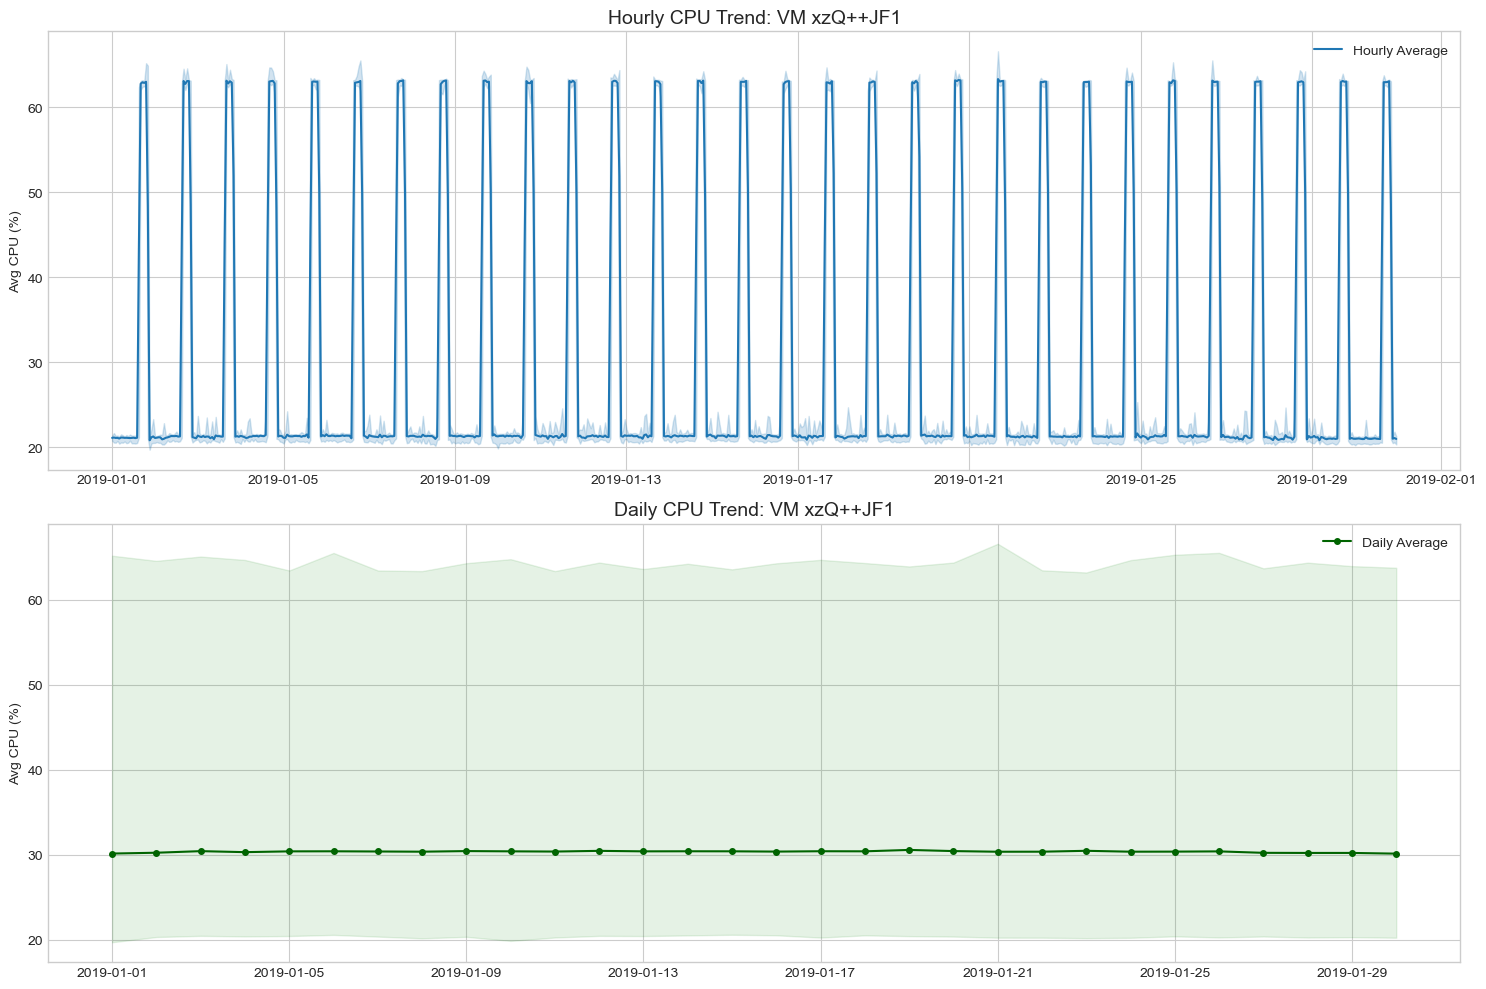

In [28]:
def plot_multi_scale_trends(df, vm_id):
    """
    Plots dual-resolution CPU utilization trends with variance shading.
    """
    vm_data = df[df['vm_id'] == vm_id].set_index('datetime').sort_index()
    
    # Aggregation using updated frequency aliases ('h' and 'd')
    hourly = vm_data['avg_cpu'].resample('h').agg(['mean', 'min', 'max'])
    daily = vm_data['avg_cpu'].resample('d').agg(['mean', 'min', 'max'])
    
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))
    
    # Hourly Visualization
    axes[0].plot(hourly.index, hourly['mean'], color='#1f77b4', label='Hourly Average', linewidth=1.5)
    axes[0].fill_between(hourly.index, hourly['min'], hourly['max'], alpha=0.2, color='#1f77b4')
    axes[0].set_title(f"Hourly CPU Trend: VM {vm_id[:8]}", fontsize=14)
    axes[0].set_ylabel("Avg CPU (%)")
    axes[0].legend()
    
    # Daily Visualization
    axes[1].plot(daily.index, daily['mean'], marker='o', color='darkgreen', label='Daily Average', markersize=4)
    axes[1].fill_between(daily.index, daily['min'], daily['max'], alpha=0.1, color='green')
    axes[1].set_title(f"Daily CPU Trend: VM {vm_id[:8]}", fontsize=14)
    axes[1].set_ylabel("Avg CPU (%)")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

# Visualize a sample VM (e.g., from the Interactive category)
sample_vm = df_meta[df_meta['vm_category'] == 'Interactive']['vm_id'].iloc[0]
plot_multi_scale_trends(df_processed, sample_vm)

## Part 4: Autocorrelation Structure (ACF & PACF)
### Objective
Analyze the internal correlation structure to determine the dependency of current values on past observations. This is crucial for identifying AR (Auto-Regressive) and MA (Moving Average) components.

### Interpreting the Plots
* **ACF**: Measures the total correlation between the series and its lags.
* **PACF**: Measures the correlation between the series and its lags after removing the effect of intermediate lags.
* **Blue Dashed Lines**: Indicate the 95% confidence interval; values outside this range are statistically significant.

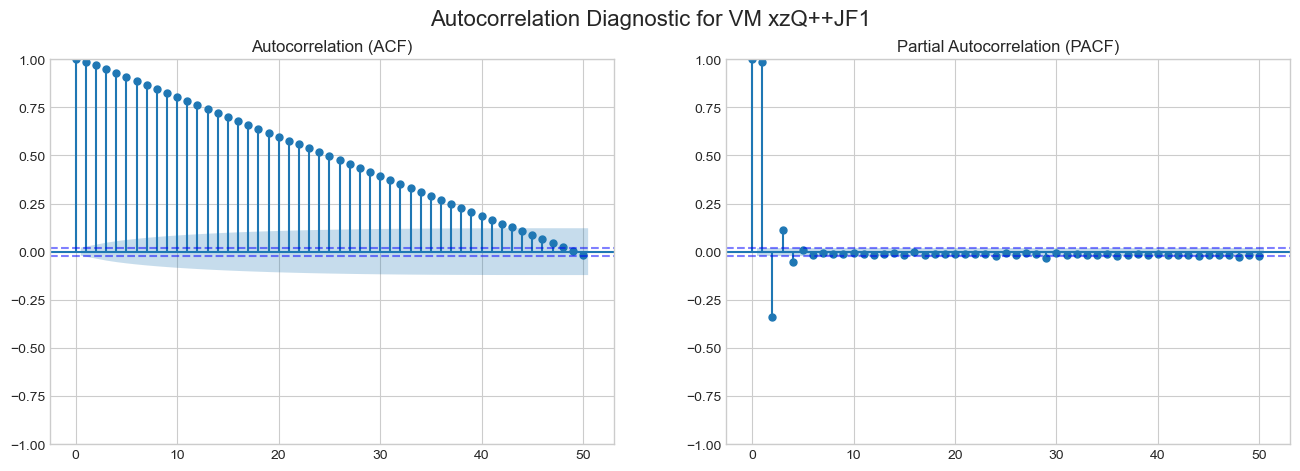

In [30]:
def plot_correlation_diagnostics(vm_id, df, lags=50):
    """
    Plots the ACF and PACF for identifying the optimal order of time series models.
    """
    series = df[df['vm_id'] == vm_id].sort_values('datetime')['avg_cpu']
    
    # Compute the 95% confidence threshold
    ci_bound = 1.96 / np.sqrt(len(series))
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Autocorrelation Function Plot
    plot_acf(series, lags=lags, ax=axes[0], title="Autocorrelation (ACF)")
    axes[0].axhline(y=ci_bound, color='blue', linestyle='--', alpha=0.5)
    axes[0].axhline(y=-ci_bound, color='blue', linestyle='--', alpha=0.5)
    
    # Partial Autocorrelation Function Plot
    plot_pacf(series, lags=lags, ax=axes[1], title="Partial Autocorrelation (PACF)", method='ols')
    axes[1].axhline(y=ci_bound, color='blue', linestyle='--', alpha=0.5)
    axes[1].axhline(y=-ci_bound, color='blue', linestyle='--', alpha=0.5)
    
    plt.suptitle(f"Autocorrelation Diagnostic for VM {vm_id[:8]}", fontsize=16)
    plt.show()

plot_correlation_diagnostics(sample_vm, df_processed)

## Part 5: STL Decomposition
### Objective
Decompose the complex CPU signal into its fundamental components using Seasonal-Trend decomposition based on LOESS (STL).

### Components Explained
1. **Trend**: The long-term direction of the data (e.g., gradual workload increase).
2. **Seasonal**: Periodic fluctuations that repeat within a fixed interval (e.g., 24-hour cycles).
3. **Residual (Resid)**: The unexplained "noise" or irregular anomalies left after removing trend and seasonality.

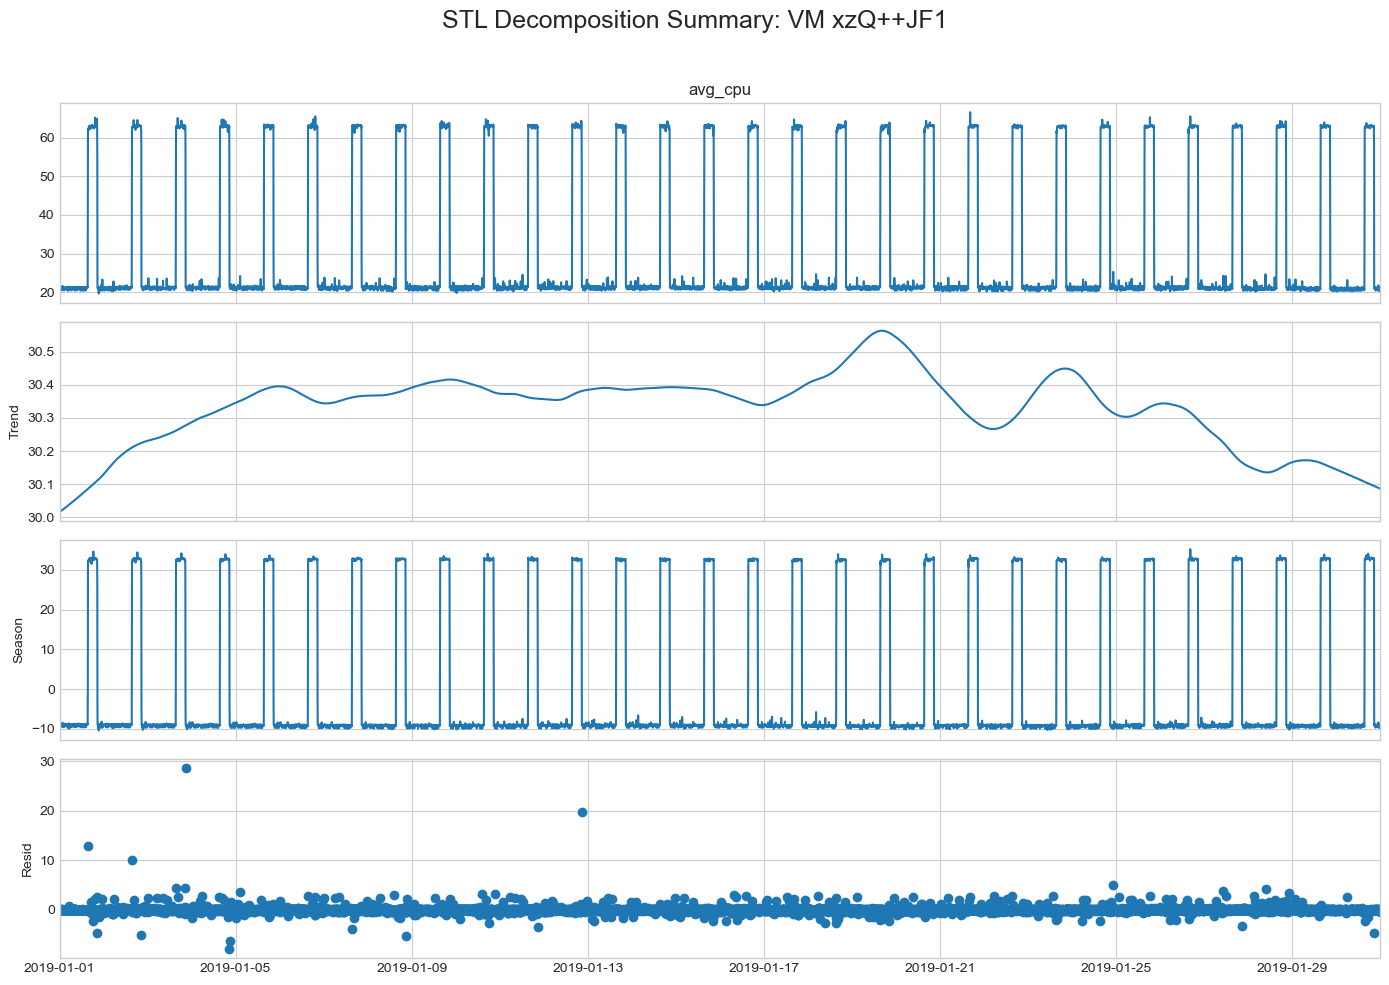

In [32]:
def perform_stl_decomposition(df, vm_id, period=288):
    """
    Deconstructs the series into Trend, Seasonal, and Residual components.
    
    Args:
        period (int): Number of observations in a full cycle. 
                     (e.g., 288 for 24 hours if data is sampled every 5 minutes).
    """
    # Prepare the series and ensure constant frequency for STL
    series = df[df['vm_id'] == vm_id].sort_values('datetime').set_index('datetime')['avg_cpu']
    
    # Resample to ensure no missing time steps and forward-fill gaps
    series = series.asfreq('300s').ffill()
    
    # Execute STL decomposition; robust=True minimizes the influence of outliers/spikes
    stl = STL(series, period=period, robust=True)
    res = stl.fit()
    
    # Visualization
    fig = res.plot()
    fig.set_size_inches(14, 10)
    plt.suptitle(f"STL Decomposition Summary: VM {vm_id[:8]}", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Run decomposition assuming potential 24-hour seasonality
perform_stl_decomposition(df_processed, sample_vm)